In [1]:
from astropy.io import fits
import numpy as np
import math 
import matplotlib.pyplot as plt
from scipy.stats import skew

In [2]:
file = '/Users/jacob/Documents/Hawaii Research Project/master_files/master_file.fits'
hdul = fits.open(file)
data = hdul[1].data 
dimm_values = data['dimm_value']
mass_values = data['mass_value']
ground_layer_values = data['seeing_gl']

## Sturges' Rule

$$
k = 1 + \log_{2}(n)
$$
$$
k = \text{The number of bins}
$$
$$
n = \text{The number of data points}
$$

In [11]:
def sturge_hist(data, title):
    
    n = len(data)
    k = int(1 + math.log2(n))
    counts, bin_edges = np.histogram(data, bins=k)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    cdf = np.cumsum(counts)
    cdf = cdf / cdf[-1]

    # Print the max, min, median and standard deviation of data
    print("The max value is: ",round(max(data),4))
    print("The min value is: ", round(min(data),4))
    print("The median value is: ", round(np.median(data),4))
    print("The std value is: ", round(np.std(data),4))
    print("-------------")

    for i in range(len(counts)):
        print(f"Bin {i+1}: Range ({bin_edges[i]:.2f}, {bin_edges[i+1]:.2f}) -> {counts[i]} entries")

    median = np.percentile(data, 50)

    fig, ax1 = plt.subplots()

    # Histogram on primary axis
    ax1.hist(data, bins=bin_centers, color='lightblue', edgecolor='black', alpha=0.6)
    ax1.set_xlabel(f'{title} Value', fontsize = 12)
    ax1.set_ylabel('Frequency', color='blue', fontsize = 12)
    ax1.tick_params(axis='y', labelcolor='blue')

    # CDF on secondary axis
    ax2 = ax1.twinx()
    ax2.plot(bin_centers, cdf, color='darkred', linewidth=2)
    ax2.set_ylabel('Cumulative Probability', color='darkred', fontsize = 12)
    ax2.tick_params(axis='y', labelcolor='darkred')
    ax2.set_ylim(0, 1.05)  # important to cap y-axis of CDF at 1

    # Draw percentile lines
    ax2.axvline(median, color='green', linestyle='--', linewidth=2)

    # Title
    plt.title("Histogram with CDF Overlay (Sturges' Rule)", fontsize = 14)
    fig.tight_layout()
    plt.show()

### DIMM Values

The max value is:  4.95
The min value is:  0.18
The median value is:  0.63
The std value is:  0.3254
-------------
Bin 1: Range (0.18, 0.42) -> 59753 entries
Bin 2: Range (0.42, 0.66) -> 236144 entries
Bin 3: Range (0.66, 0.90) -> 147585 entries
Bin 4: Range (0.90, 1.13) -> 58694 entries
Bin 5: Range (1.13, 1.37) -> 23653 entries
Bin 6: Range (1.37, 1.61) -> 10653 entries
Bin 7: Range (1.61, 1.85) -> 5172 entries
Bin 8: Range (1.85, 2.09) -> 2836 entries
Bin 9: Range (2.09, 2.33) -> 1550 entries
Bin 10: Range (2.33, 2.57) -> 907 entries
Bin 11: Range (2.57, 2.80) -> 535 entries
Bin 12: Range (2.80, 3.04) -> 338 entries
Bin 13: Range (3.04, 3.28) -> 199 entries
Bin 14: Range (3.28, 3.52) -> 143 entries
Bin 15: Range (3.52, 3.76) -> 79 entries
Bin 16: Range (3.76, 4.00) -> 41 entries
Bin 17: Range (4.00, 4.23) -> 18 entries
Bin 18: Range (4.23, 4.47) -> 8 entries
Bin 19: Range (4.47, 4.71) -> 11 entries
Bin 20: Range (4.71, 4.95) -> 5 entries


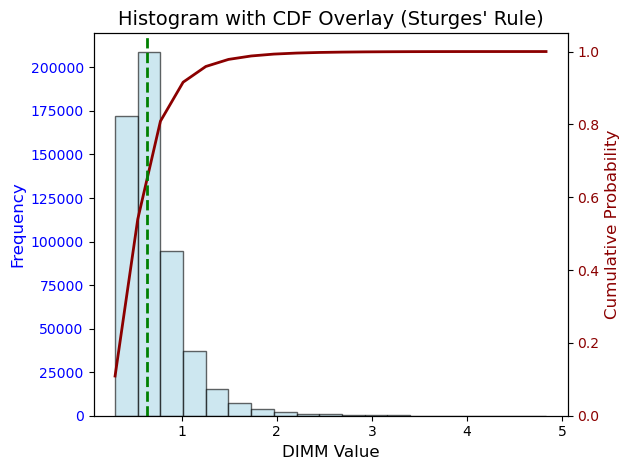

In [12]:
sturge_hist(dimm_values, "DIMM")

### MASS Values

The max value is:  4.21
The min value is:  0.0
The median value is:  0.3
The std value is:  0.2323
-------------
Bin 1: Range (0.00, 0.21) -> 176601 entries
Bin 2: Range (0.21, 0.42) -> 216186 entries
Bin 3: Range (0.42, 0.63) -> 100229 entries
Bin 4: Range (0.63, 0.84) -> 35733 entries
Bin 5: Range (0.84, 1.05) -> 11682 entries
Bin 6: Range (1.05, 1.26) -> 4401 entries
Bin 7: Range (1.26, 1.47) -> 1831 entries
Bin 8: Range (1.47, 1.68) -> 791 entries
Bin 9: Range (1.68, 1.89) -> 401 entries
Bin 10: Range (1.89, 2.10) -> 225 entries
Bin 11: Range (2.10, 2.32) -> 108 entries
Bin 12: Range (2.32, 2.53) -> 52 entries
Bin 13: Range (2.53, 2.74) -> 36 entries
Bin 14: Range (2.74, 2.95) -> 30 entries
Bin 15: Range (2.95, 3.16) -> 6 entries
Bin 16: Range (3.16, 3.37) -> 7 entries
Bin 17: Range (3.37, 3.58) -> 1 entries
Bin 18: Range (3.58, 3.79) -> 1 entries
Bin 19: Range (3.79, 4.00) -> 1 entries
Bin 20: Range (4.00, 4.21) -> 2 entries


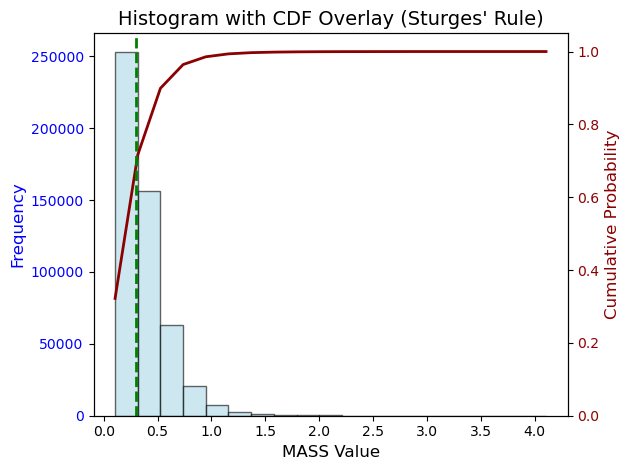

In [13]:
sturge_hist(mass_values, "MASS")

### Ground Layer Seeing Values

The max value is:  4.78
The min value is:  0.0
The median value is:  0.469
The std value is:  0.311
-------------
Bin 1: Range (0.00, 0.24) -> 52352 entries
Bin 2: Range (0.24, 0.48) -> 231898 entries
Bin 3: Range (0.48, 0.72) -> 160648 entries
Bin 4: Range (0.72, 0.96) -> 60751 entries
Bin 5: Range (0.96, 1.20) -> 23105 entries
Bin 6: Range (1.20, 1.43) -> 9388 entries
Bin 7: Range (1.43, 1.67) -> 4623 entries
Bin 8: Range (1.67, 1.91) -> 2380 entries
Bin 9: Range (1.91, 2.15) -> 1276 entries
Bin 10: Range (2.15, 2.39) -> 718 entries
Bin 11: Range (2.39, 2.63) -> 475 entries
Bin 12: Range (2.63, 2.87) -> 271 entries
Bin 13: Range (2.87, 3.11) -> 195 entries
Bin 14: Range (3.11, 3.35) -> 109 entries
Bin 15: Range (3.35, 3.59) -> 69 entries
Bin 16: Range (3.59, 3.82) -> 39 entries
Bin 17: Range (3.82, 4.06) -> 15 entries
Bin 18: Range (4.06, 4.30) -> 6 entries
Bin 19: Range (4.30, 4.54) -> 4 entries
Bin 20: Range (4.54, 4.78) -> 2 entries


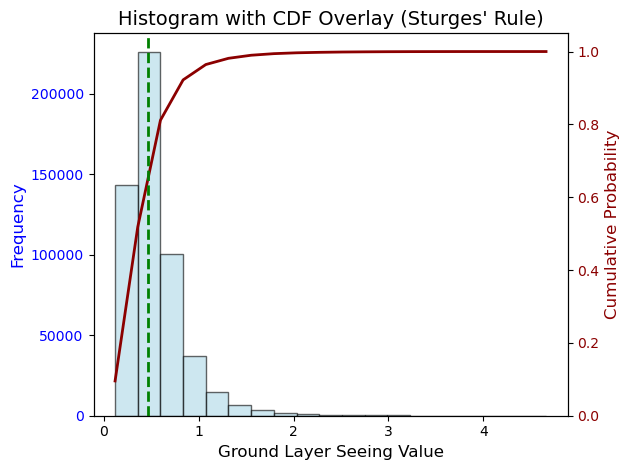

In [14]:
sturge_hist(ground_layer_values, "Ground Layer Seeing")

# ____________________________________________________________________

## Doane's Rule

$$
k = 1 + \log_{2}(n) + \log_{2}(1 + \frac{|\text{skewness}|}{\sigma_{g1}})
$$
$$
k = \text{The number of bins}
$$
$$
n = \text{The number of data points}
$$
$$
\text{skewness = sample skewness of the data}
$$
$$
\sigma_{g1} = \sqrt{\frac{6(n-2)}{(n+1)(n+3)}} \text{(standard error of skewness)}
$$

In [20]:
def doane_hist(data, title):

    n = len(data)

    # Calculate sample skewness
    data_skewness = skew(data)

    # Calculate standard error of skewness
    sigma_g1 = np.sqrt(6*(n-2) / ((n+1)*(n+3)))

    # Calculate number of bins using Doane’s Rule
    k = int(np.ceil(1 + np.log2(n) + np.log2(1 + abs(data_skewness) / sigma_g1)))

    # Compute histogram counts and bin edges
    counts, bin_edges = np.histogram(data, bins=k)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    cdf = np.cumsum(counts)
    cdf = cdf / cdf[-1]

    # Print the max, min, median and standard deviation of data
    print("The max value is: ",round(max(data),4))
    print("The min value is: ", round(min(data),4))
    print("The median value is: ", round(np.median(data),4))
    print("The std value is: ", round(np.std(data),4))
    print("-------------")

    for i in range(len(counts)):
        print(f"Bin {i+1}: Range ({bin_edges[i]:.2f}, {bin_edges[i+1]:.2f}) -> {counts[i]} entries")

    median = np.percentile(data, 50)
    
    fig, ax1 = plt.subplots()

    # Histogram on primary axis
    ax1.hist(data, bins=bin_centers, color='lightblue', edgecolor='black', alpha=0.6)
    ax1.set_xlabel(f'{title} Value', fontsize = 12)
    ax1.set_ylabel('Frequency', color='blue', fontsize = 12)
    ax1.tick_params(axis='y', labelcolor='blue')

    # CDF on secondary axis
    ax2 = ax1.twinx()
    ax2.plot(bin_centers, cdf, color='darkred', linewidth=2)
    ax2.set_ylabel('Cumulative Probability', color='darkred', fontsize = 12)
    ax2.tick_params(axis='y', labelcolor='darkred')
    ax2.set_ylim(0, 1.05)  # important to cap y-axis of CDF at 1

    # Draw percentile lines
    ax2.axvline(median, color='green', linestyle='--', linewidth=2)

    # Title
    plt.title("Histogram with CDF Overlay (Doane's Rule)", fontsize = 14)
    fig.tight_layout()
    plt.show()

### DIMM Values

The max value is:  4.95
The min value is:  0.18
The median value is:  0.63
The std value is:  0.3254
-------------
Bin 1: Range (0.18, 0.34) -> 14059 entries
Bin 2: Range (0.34, 0.50) -> 120079 entries
Bin 3: Range (0.50, 0.66) -> 161759 entries
Bin 4: Range (0.66, 0.82) -> 111937 entries
Bin 5: Range (0.82, 0.98) -> 61482 entries
Bin 6: Range (0.98, 1.13) -> 32860 entries
Bin 7: Range (1.13, 1.29) -> 17961 entries
Bin 8: Range (1.29, 1.45) -> 10214 entries
Bin 9: Range (1.45, 1.61) -> 6131 entries
Bin 10: Range (1.61, 1.77) -> 3747 entries
Bin 11: Range (1.77, 1.93) -> 2548 entries
Bin 12: Range (1.93, 2.09) -> 1713 entries
Bin 13: Range (2.09, 2.25) -> 1096 entries
Bin 14: Range (2.25, 2.41) -> 808 entries
Bin 15: Range (2.41, 2.57) -> 553 entries
Bin 16: Range (2.57, 2.72) -> 382 entries
Bin 17: Range (2.72, 2.88) -> 295 entries
Bin 18: Range (2.88, 3.04) -> 196 entries
Bin 19: Range (3.04, 3.20) -> 144 entries
Bin 20: Range (3.20, 3.36) -> 112 entries
Bin 21: Range (3.36, 3.52) -> 

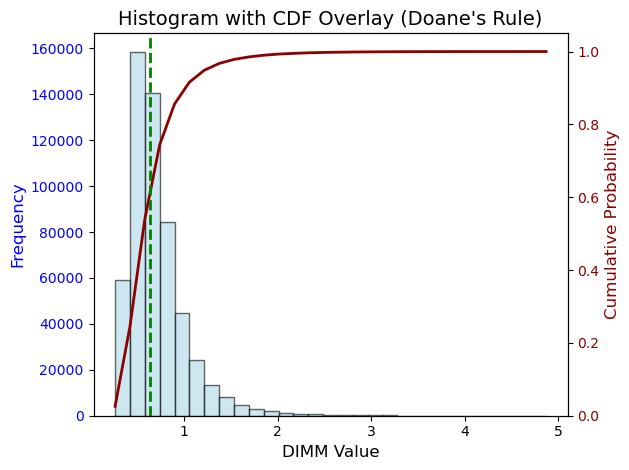

In [21]:
doane_hist(dimm_values, 'DIMM')

### MASS Values

The max value is:  4.21
The min value is:  0.0
The median value is:  0.3
The std value is:  0.2323
-------------
Bin 1: Range (0.00, 0.14) -> 87211 entries
Bin 2: Range (0.14, 0.28) -> 175103 entries
Bin 3: Range (0.28, 0.42) -> 130473 entries
Bin 4: Range (0.42, 0.56) -> 76587 entries
Bin 5: Range (0.56, 0.70) -> 40247 entries
Bin 6: Range (0.70, 0.84) -> 19128 entries
Bin 7: Range (0.84, 0.98) -> 9008 entries
Bin 8: Range (0.98, 1.12) -> 4586 entries
Bin 9: Range (1.12, 1.26) -> 2489 entries
Bin 10: Range (1.26, 1.40) -> 1359 entries
Bin 11: Range (1.40, 1.54) -> 786 entries
Bin 12: Range (1.54, 1.68) -> 477 entries
Bin 13: Range (1.68, 1.82) -> 308 entries
Bin 14: Range (1.82, 1.96) -> 171 entries
Bin 15: Range (1.96, 2.10) -> 147 entries
Bin 16: Range (2.10, 2.25) -> 79 entries
Bin 17: Range (2.25, 2.39) -> 53 entries
Bin 18: Range (2.39, 2.53) -> 28 entries
Bin 19: Range (2.53, 2.67) -> 29 entries
Bin 20: Range (2.67, 2.81) -> 21 entries
Bin 21: Range (2.81, 2.95) -> 16 entries
Bi

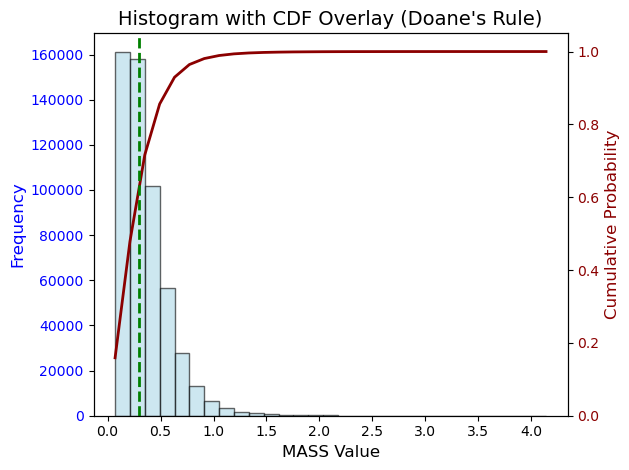

In [22]:
doane_hist(mass_values, 'MASS')

### Ground Layer Seeing Values

The max value is:  4.78
The min value is:  0.0
The median value is:  0.469
The std value is:  0.311
-------------
Bin 1: Range (0.00, 0.16) -> 20983 entries
Bin 2: Range (0.16, 0.32) -> 93798 entries
Bin 3: Range (0.32, 0.48) -> 169469 entries
Bin 4: Range (0.48, 0.64) -> 122583 entries
Bin 5: Range (0.64, 0.80) -> 65187 entries
Bin 6: Range (0.80, 0.96) -> 33629 entries
Bin 7: Range (0.96, 1.12) -> 17553 entries
Bin 8: Range (1.12, 1.27) -> 9445 entries
Bin 9: Range (1.27, 1.43) -> 5495 entries
Bin 10: Range (1.43, 1.59) -> 3411 entries
Bin 11: Range (1.59, 1.75) -> 2197 entries
Bin 12: Range (1.75, 1.91) -> 1395 entries
Bin 13: Range (1.91, 2.07) -> 932 entries
Bin 14: Range (2.07, 2.23) -> 637 entries
Bin 15: Range (2.23, 2.39) -> 425 entries
Bin 16: Range (2.39, 2.55) -> 358 entries
Bin 17: Range (2.55, 2.71) -> 214 entries
Bin 18: Range (2.71, 2.87) -> 174 entries
Bin 19: Range (2.87, 3.03) -> 150 entries
Bin 20: Range (3.03, 3.19) -> 86 entries
Bin 21: Range (3.19, 3.35) -> 69 en

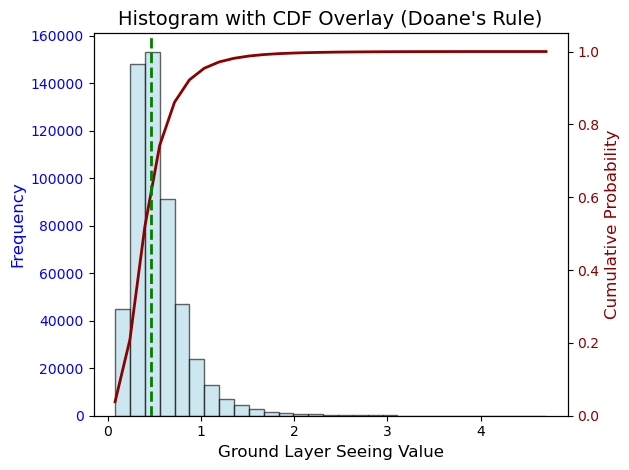

In [23]:
doane_hist(ground_layer_values, 'Ground Layer Seeing')

# ____________________________________________________________________

## Rice's Rule

$$
k = [ 2\times{n^{1/3}} ]
$$
$$
k = \text{The number of bins}
$$
$$
n = \text{The number of data points}
$$

In [24]:
def rice_hist(data, title):

    n = len(data)

    # Calculate number of bins using Rice's Rule
    k = int(np.ceil(2 * n**(1/3)))

    # Compute histogram counts and edges
    counts, bin_edges = np.histogram(data, bins=k)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    cdf = np.cumsum(counts)
    cdf = cdf / cdf[-1]

    # Print the max, min, median and standard deviation of data
    print("The max value is: ",round(max(data),4))
    print("The min value is: ", round(min(data),4))
    print("The median value is: ", round(np.median(data),4))
    print("The std value is: ", round(np.std(data),4))
    print("-------------")

    # Print entries per bin
    for i in range(len(counts)):
        print(f"Bin {i+1}: Range ({bin_edges[i]:.2f} to {bin_edges[i+1]:.2f}) contains {counts[i]} values")

    median = np.percentile(data, 50)

    fig, ax1 = plt.subplots()

    # Histogram on primary axis
    ax1.hist(data, bins=bin_centers, color='lightblue', edgecolor='black', alpha=0.6)
    ax1.set_xlabel(f'{title} Value', fontsize = 12)
    ax1.set_ylabel('Frequency', color='blue', fontsize = 12)
    ax1.tick_params(axis='y', labelcolor='blue')

    # CDF on secondary axis
    ax2 = ax1.twinx()
    ax2.plot(bin_centers, cdf, color='darkred', linewidth=2)
    ax2.set_ylabel('Cumulative Probability', color='darkred', fontsize = 12)
    ax2.tick_params(axis='y', labelcolor='darkred')
    ax2.set_ylim(0, 1.05)  # important to cap y-axis of CDF at 1

    # Draw percentile lines
    ax2.axvline(median, color='green', linestyle='--', linewidth=2)

    # Title
    plt.title("Histogram with CDF Overlay (Rice's Rule)", fontsize = 14)
    fig.tight_layout()
    plt.show()

### DIMM Values

The max value is:  4.95
The min value is:  0.18
The median value is:  0.63
The std value is:  0.3254
-------------
Bin 1: Range (0.18 to 0.21) contains 33 values
Bin 2: Range (0.21 to 0.24) contains 192 values
Bin 3: Range (0.24 to 0.27) contains 965 values
Bin 4: Range (0.27 to 0.30) contains 2960 values
Bin 5: Range (0.30 to 0.33) contains 6660 values
Bin 6: Range (0.33 to 0.35) contains 11455 values
Bin 7: Range (0.35 to 0.38) contains 16270 values
Bin 8: Range (0.38 to 0.41) contains 21177 values
Bin 9: Range (0.41 to 0.44) contains 25331 values
Bin 10: Range (0.44 to 0.47) contains 28720 values
Bin 11: Range (0.47 to 0.50) contains 20386 values
Bin 12: Range (0.50 to 0.53) contains 31328 values
Bin 13: Range (0.53 to 0.56) contains 31786 values
Bin 14: Range (0.56 to 0.59) contains 31408 values
Bin 15: Range (0.59 to 0.62) contains 30098 values
Bin 16: Range (0.62 to 0.65) contains 28137 values
Bin 17: Range (0.65 to 0.67) contains 26157 values
Bin 18: Range (0.67 to 0.70) contain

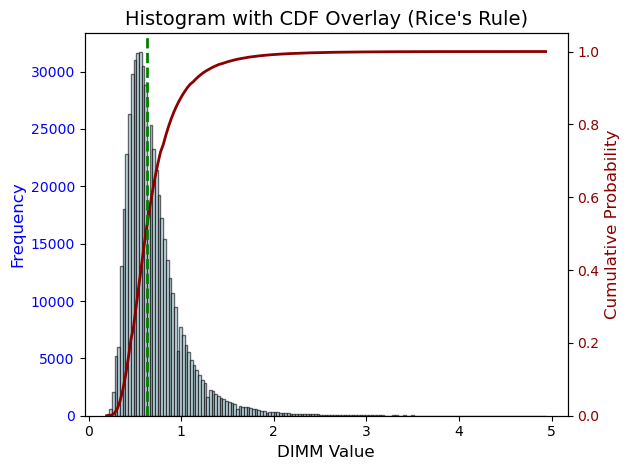

In [25]:
rice_hist(dimm_values, 'DIMM')

### MASS Values

The max value is:  4.21
The min value is:  0.0
The median value is:  0.3
The std value is:  0.2323
-------------
Bin 1: Range (0.00 to 0.03) contains 1202 values
Bin 2: Range (0.03 to 0.05) contains 624 values
Bin 3: Range (0.05 to 0.08) contains 13443 values
Bin 4: Range (0.08 to 0.10) contains 26865 values
Bin 5: Range (0.10 to 0.13) contains 21445 values
Bin 6: Range (0.13 to 0.15) contains 36016 values
Bin 7: Range (0.15 to 0.18) contains 25594 values
Bin 8: Range (0.18 to 0.21) contains 38609 values
Bin 9: Range (0.21 to 0.23) contains 38274 values
Bin 10: Range (0.23 to 0.26) contains 24758 values
Bin 11: Range (0.26 to 0.28) contains 35484 values
Bin 12: Range (0.28 to 0.31) contains 22455 values
Bin 13: Range (0.31 to 0.33) contains 30981 values
Bin 14: Range (0.33 to 0.36) contains 19080 values
Bin 15: Range (0.36 to 0.39) contains 26525 values
Bin 16: Range (0.39 to 0.41) contains 23970 values
Bin 17: Range (0.41 to 0.44) contains 14459 values
Bin 18: Range (0.44 to 0.46) con

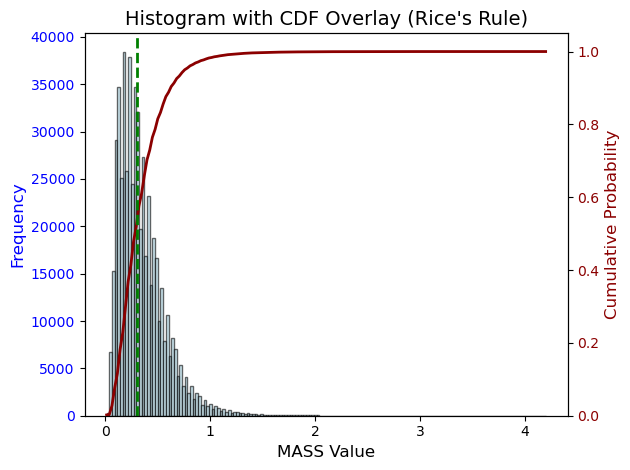

In [26]:
rice_hist(mass_values, 'MASS')

### Ground Layer Seeing Values

The max value is:  4.78
The min value is:  0.0
The median value is:  0.469
The std value is:  0.311
-------------
Bin 1: Range (0.00 to 0.03) contains 3832 values
Bin 2: Range (0.03 to 0.06) contains 252 values
Bin 3: Range (0.06 to 0.09) contains 3918 values
Bin 4: Range (0.09 to 0.12) contains 4174 values
Bin 5: Range (0.12 to 0.15) contains 5406 values
Bin 6: Range (0.15 to 0.17) contains 7293 values
Bin 7: Range (0.17 to 0.20) contains 10297 values
Bin 8: Range (0.20 to 0.23) contains 13677 values
Bin 9: Range (0.23 to 0.26) contains 18097 values
Bin 10: Range (0.26 to 0.29) contains 23221 values
Bin 11: Range (0.29 to 0.32) contains 27240 values
Bin 12: Range (0.32 to 0.35) contains 29331 values
Bin 13: Range (0.35 to 0.38) contains 31744 values
Bin 14: Range (0.38 to 0.41) contains 32610 values
Bin 15: Range (0.41 to 0.44) contains 30819 values
Bin 16: Range (0.44 to 0.47) contains 30307 values
Bin 17: Range (0.47 to 0.50) contains 27882 values
Bin 18: Range (0.50 to 0.52) contai

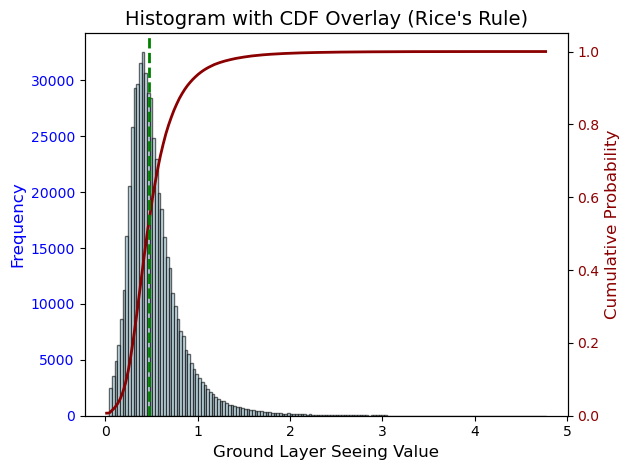

In [27]:
rice_hist(ground_layer_values, 'Ground Layer Seeing')